Моделирование мотивов и PWM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
background = {'A': 0.295, 'T': 0.295, 'G': 0.205, 'C': 0.205}

## Задание 1

In [13]:
sites = [
    "GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
    "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
    "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
    "CAGGTTGGC"
]
nucleotides=['A', 'C', 'G', 'T']
enumerate(nucleotides)
def build_pfm(sites, nucleotides = nucleotides):
    pfm = np.zeros((len(nucleotides), len(sites[0])), dtype=int)
    nuc_idx = {n: i for i, n in enumerate(nucleotides)}
    for gen in sites:
        for i, n in enumerate(gen):
            if n in nuc_idx:
                pfm[nuc_idx[n], i] += 1
    return pfm

pfm = build_pfm(sites)
print(pfm)

[[ 1  8  1  0  0  2  7  2  1]
 [ 6  2  1  0  0  6  0  0  8]
 [ 1  0  8 10  0  0  3  8  0]
 [ 2  0  0  0 10  2  0  0  1]]


In [18]:
def pfm_to_ppm(pfm, alpha=0.1):
    n = pfm.sum(axis=0)
    ppm = (pfm + alpha) / (n + 4 * alpha)
    return ppm

ppm = pfm_to_ppm(pfm, alpha=0.1)
print(ppm)

[[0.10576923 0.77884615 0.10576923 0.00961538 0.00961538 0.20192308
  0.68269231 0.20192308 0.10576923]
 [0.58653846 0.20192308 0.10576923 0.00961538 0.00961538 0.58653846
  0.00961538 0.00961538 0.77884615]
 [0.10576923 0.00961538 0.77884615 0.97115385 0.00961538 0.00961538
  0.29807692 0.77884615 0.00961538]
 [0.20192308 0.00961538 0.00961538 0.00961538 0.97115385 0.20192308
  0.00961538 0.00961538 0.10576923]]


In [19]:
def ppm_to_pwm(ppm, bg=background, nucleotides = nucleotides):
    bg_vec = np.array([bg[b] for b in nucleotides]).reshape(-1, 1)
    pwm = np.log2(ppm / bg_vec)
    return pwm

pwm = ppm_to_pwm(ppm)
print(pwm)

[[-1.47979496  1.40062343 -1.47979496 -4.93922658 -4.93922658 -0.54690915
   1.21052054 -0.54690915 -1.47979496]
 [ 1.5166018  -0.02181811 -0.95470391 -4.41413553 -4.41413553  1.5166018
  -4.41413553 -4.41413553  1.92571447]
 [-0.95470391 -4.41413553  1.92571447  2.24407595 -4.41413553 -4.41413553
   0.54006078  1.92571447 -4.41413553]
 [-0.54690915 -4.93922658 -4.93922658 -4.93922658  1.71898491 -0.54690915
  -4.93922658 -4.93922658 -1.47979496]]


In [21]:
def score_sequence(seq, pwm, nucleotides = nucleotides):
    nuc_idx = {n: i for i, n in enumerate(nucleotides)}
    return sum(pwm[nuc_idx[seq[pos]], pos] for pos in range(len(seq)))

max_seq = ''.join(nucleotides[np.argmax(pwm[:, pos])] for pos in range(len(pwm[0])))
min_seq = ''.join(nucleotides[np.argmin(pwm[:, pos])] for pos in range(len(pwm[0])))

max_score = score_sequence(max_seq, pwm)
min_score = score_sequence(min_seq, pwm)

print(f"Максимальный скор: {max_score:.3f}, последовательность: {max_seq}")
print(f"Минимальный скор: {min_score:.3f}, последовательность: {min_seq}")

Максимальный скор: 15.385, последовательность: CAGGTCAGC
Минимальный скор: -39.943, последовательность: ATTAAGTTG


## Задание 2

In [26]:
from Bio import motifs, SeqIO
from Bio.Seq import Seq

instances = [Seq(s) for s in sites]
m = motifs.create(instances)

print(f"Консенсусная последовательность: {m.consensus}")

print('pwm мотива biopython','\n', m.pwm)

Консенсусная последовательность: CAGGTCAGC
pwm мотива biopython 
         0      1      2      3      4      5      6      7      8
A:   0.10   0.80   0.10   0.00   0.00   0.20   0.70   0.20   0.10
C:   0.60   0.20   0.10   0.00   0.00   0.60   0.00   0.00   0.80
G:   0.10   0.00   0.80   1.00   0.00   0.00   0.30   0.80   0.00
T:   0.20   0.00   0.00   0.00   1.00   0.20   0.00   0.00   0.10



In [30]:
record = next(SeqIO.parse('chr1.fa\chr1.fa', 'fasta'))
sequence = record.seq[:1_000_000]

In [35]:
hits = []

for pos, score in m.pssm.search(sequence, threshold=5.0):
        hits.append((pos, '+', round(score, 3)))

rc_sequence = sequence.reverse_complement()
for pos, score in m.pssm.search(rc_sequence, threshold=5.0):
        # Переводим позицию в координаты прямой цепи
        real_pos = len(sequence) - pos - L
        hits.append((real_pos, '-', round(score, 3)))

print('Хиты со скором > 5.0:')
print('Позиция, цепь, скор')
for pos, strand, score in hits:
        print(f"{pos:}  {strand:}  {score:8.3f}")

Хиты со скором > 5.0:
Позиция, цепь, скор
-9495  +    11.724
-8993  +     6.916
-8674  +     5.554
-8355  +     5.554
-8127  +     8.139
11876  +     7.139
-8104  +     7.139
-7983  +     6.139
12224  +     5.139
-7319  +    10.501
-6861  +     8.916
13330  +     7.139
13460  +     6.331
13867  +     7.554
14056  +     5.501
-5754  +     7.139
14280  +    14.724
15148  +     8.139
-3987  +     5.554
-3880  +     6.139
-3144  +     6.331
16938  +    13.501
16986  +     8.916
-2633  +     5.331
17811  +     9.724
-1501  +     5.916
-1447  +    11.724
-1426  +     5.139
19143  +     5.554
19481  +     6.331
19915  +     5.331
39910  -     5.331
39476  -     6.331
39138  -     5.554
18569  -     5.139
18548  -    11.724
18494  -     5.916
37806  -     9.724
17362  -     5.331
36981  -     8.916
36933  -    13.501
16851  -     6.331
16115  -     6.139
16008  -     5.554
35143  -     8.139
34275  -    14.724
14241  -     7.139
34051  -     5.501
33862  -     7.554
33455  -     6.331
33325  -

## Задание 3

In [ ]:
def generate_random_sequences(n, length, bg=background, nucleotides = nucleotides):
    probs = [bg[n] for n in nucleotides]
    seqs = np.random.choice(list(nucleotides), size=(n, length), p=probs)
    return seqs
L = 9
N = 100000
random_seqs = generate_random_sequences(N, L)

In [43]:
nuc_idx = {n: i for i, n in enumerate(nucleotides)}

def score_sequences_fast(seqs, pwm, nucleotides = nucleotides):
    L = pwm.shape[1]
    scores = np.zeros(len(seqs))
    for pos in range(L):
        for n_idx, n in enumerate(nucleotides):
            mask = seqs[:, pos] == n
            scores[mask] += pwm[n_idx, pos]
    return scores

bg_scores = score_sequences_fast(random_seqs, pwm)

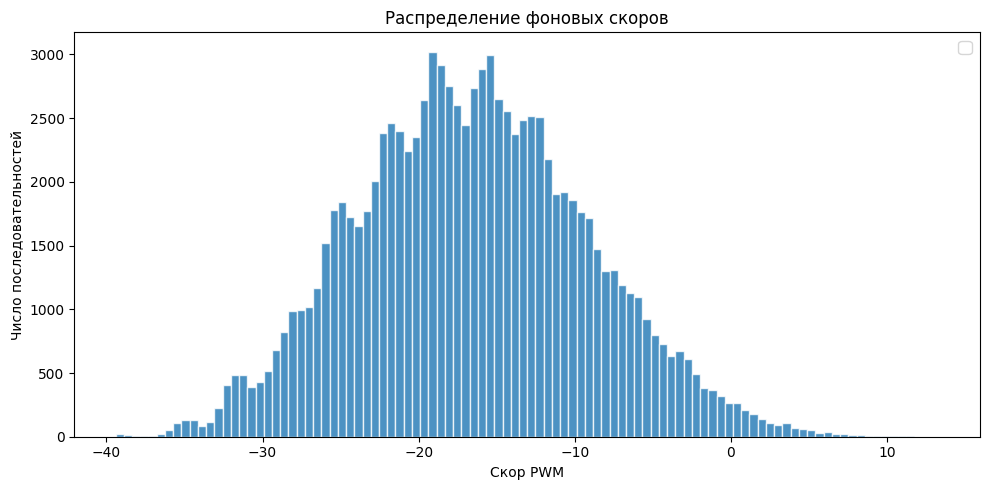

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bg_scores, bins=100, edgecolor='white', alpha=0.8)
ax.set_xlabel('Скор PWM')
ax.set_ylabel('Число последовательностей')
ax.set_title('Распределение фоновых скоров')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [46]:
def get_pvalue(score, bg_scores):
    return np.mean(bg_scores >= score)

pvalue = 1e-4
threshold_1e4 = np.percentile(bg_scores, (1 - pvalue) * 100)
print(f"\nПорог для p-value 1e-4: {threshold_1e4:.3f}")
print(f"p-value при этом пороге = {get_pvalue(threshold_1e4, bg_scores):.2e}")


Порог для p-value 1e-4: 10.441
p-value при этом пороге = 1.00e-04


## Задание 4

In [48]:
#Энтропия Шеннона
def shannon_entropy(ppm):
    log_ppm = np.where(ppm > 0, np.log2(ppm), 0)
    H = -np.sum(ppm * log_ppm, axis=0)
    return H

H = shannon_entropy(ppm)
IC = 2 - H

print("Позиция, Энтропия H(i),  Информационное содержание IC(i)")
for pos in range(L):
    print(f"  {pos+1}, {H[pos]:.4f}, {IC[pos]:.4f}")

Позиция, Энтропия H(i),  Информационное содержание IC(i)
  1, 1.6031, 0.3969
  2, 0.8758, 1.1242
  3, 1.0309, 0.9691
  4, 0.2343, 1.7657
  5, 0.2343, 1.7657
  6, 1.4480, 0.5520
  7, 1.0253, 0.9747
  8, 0.8758, 1.1242
  9, 1.0309, 0.9691


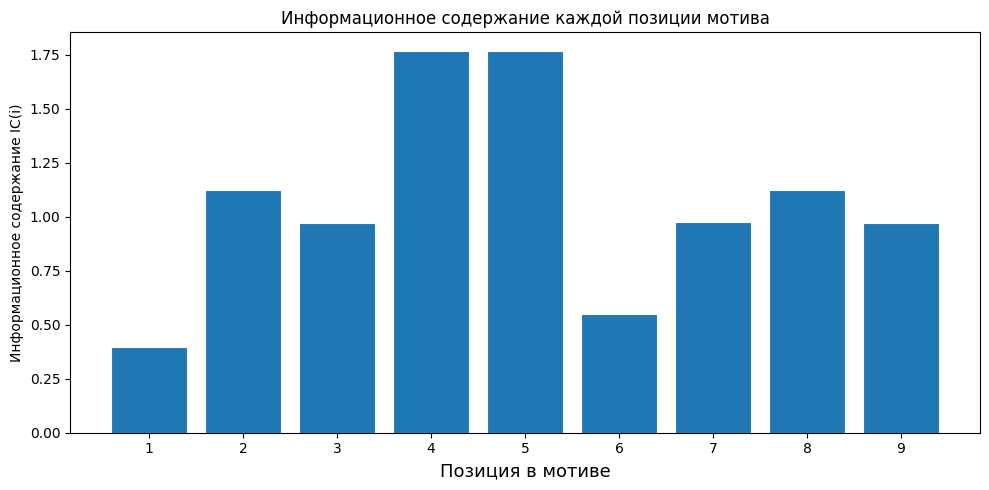

In [56]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(1, L+1), IC, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Позиция в мотиве', fontsize=13)
ax.set_ylabel('Информационное содержание IC(i)')
ax.set_title('Информационное содержание каждой позиции мотива')
ax.set_xticks(range(1, L+1))

plt.tight_layout()
plt.show()

Позиции с высоким IC 4 и 5 (IC одно из самых больших) являются кор мотивами, они важны для связывания. Вариабельные позиции (остальные кроме 4 и 5) допускают замены нуклеотидов (хотя к примеру 2, 3, 8, 9 более консервативны, их не стоит заменять, мб потеряется функция).

В кор-позициях большинство сайтов содержат одну и ту же букву, для позиции 4 это буква G, для позиции 5 буква T

Марковские цепи

## Задание 5

In [59]:
from Bio import SeqIO
record = SeqIO.read("sequence.fasta", "fasta")
seq = str(record.seq)

In [63]:
nuc_idx = {n: i for i, n in enumerate(nucleotides)}

dinuc_counts = np.zeros((4, 4), dtype=int)
for k in range(len(seq) - 1):
    i = nuc_idx.get(seq[k], -1)
    j = nuc_idx.get(seq[k+1], -1)
    if i >= 0 and j >= 0:
        dinuc_counts[i, j] += 1

print("Матрица частот динуклеотидов: (i, j) - (A, C, G, T)")
print(dinuc_counts)

Матрица частот динуклеотидов: (i, j) - (A, C, G, T)
[[1913 1268  796 1651]
 [1365 1104  287 1220]
 [ 662  519  397  435]
 [1689 1085  532 1375]]


In [66]:
row_sums = dinuc_counts.sum(axis=1)
P = dinuc_counts / row_sums

print("Матрица переходов P: (i, j) - (A, C, G, T)")
print(P)

Матрица переходов P: (i, j) - (A, C, G, T)
[[0.3399076  0.31891348 0.39542971 0.35270241]
 [0.24253731 0.277666   0.14257327 0.26062807]
 [0.11762615 0.1305332  0.19721808 0.09292886]
 [0.30010661 0.27288732 0.26428217 0.29374065]]


In [78]:
eigenvalues, eigenvectors = np.linalg.eig(P.T)

idx = np.argmin(np.abs(eigenvalues - 1)) #ищем собственное значение примерно равное 1
pi = np.real(eigenvectors[:, idx]) # убирает мнимую часть (появляется из-за погрешностей вычислений)
pi = pi / pi.sum()  # нормируем

print("Стационарное распределение pi:")
for n, p in zip(nucleotides, pi):
    print(f"pi({n}) = {p:.4f}")

#Сравнение с наблюдаемыми частотами
print("Наблюдаемое распределение pi:")
obs_freq = {n: seq.count(n) / len(seq) for n in nucleotides}
for n, p_obs in zip(nucleotides, obs_freq.values()):
    print(f"pi({n}) = {p_obs:.4f}")

Стационарное распределение pi:
pi(A) = 0.2501
pi(C) = 0.2500
pi(G) = 0.2499
pi(T) = 0.2500
Наблюдаемое распределение pi:
pi(A) = 0.3454
pi(C) = 0.2439
pi(G) = 0.1235
pi(T) = 0.2872


## Задание 6: Вычисление P и предельное распределение

In [75]:
from numpy.linalg import matrix_power, norm

k_max = 1000
norms = []
P_prev = np.eye(4)

for k in range(1, k_max + 1):
    P_k = matrix_power(P, k)
    norms.append(norm(P_k - P_prev, 'fro'))
    P_prev = P_k.copy()

print(f"Норма при k=1:{norms[0]:.6f}")
print(f"Норма при k=10:{norms[9]:.6f}")
print(f"Норма при k=100:{norms[99]:.6f}")
print(f"Норма при k=1000:{norms[999]:.10f}")

Норма при k=1:1.704167
Норма при k=10:0.000000
Норма при k=100:0.000000
Норма при k=1000:0.0000000000


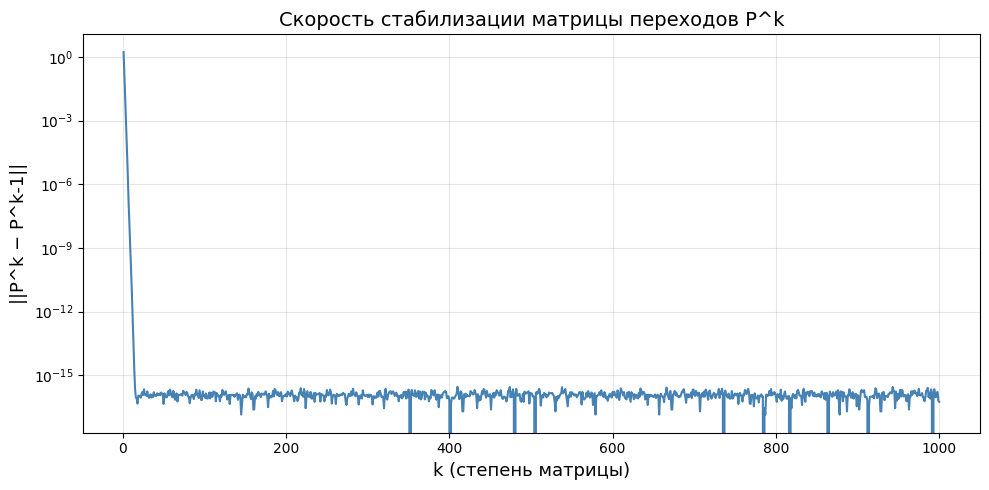

In [76]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, k_max + 1), norms, color='steelblue', linewidth=1.5)
ax.set_xlabel('k (степень матрицы)', fontsize=13)
ax.set_ylabel('||P^k − P^k-1||', fontsize=13)
ax.set_title('Скорость стабилизации матрицы переходов P^k', fontsize=14)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:

P_1000 = matrix_power(P, 1000)
print("P^1000:")
print(f"{'':4}", '  '.join(f'{b:>8}' for b in nucleotides))
for i, b in enumerate(nucleotides):
    print(f"{b:4}", '  '.join(f'{P_1000[i,j]:>8.4f}' for j in range(4)))

print("Стационарное распределение pi:")
for n, p in zip(nucleotides, pi):
    print(f"pi({n}) = {p:.4f}")

P^1000:
            A         C         G         T
A      0.3454    0.3453    0.3451    0.3453
C      0.2440    0.2440    0.2438    0.2440
G      0.1235    0.1235    0.1234    0.1235
T      0.2873    0.2872    0.2871    0.2872
Стационарное распределение pi:
pi(A) = 0.2501
pi(C) = 0.2500
pi(G) = 0.2499
pi(T) = 0.2500


У меня здесь стационарное распределение записано по столбцам, они одинаковые. Не совпадают со стационарным распределением.